# S8 — Policy learning and ROI simulation

This section is post-confirmatory and exploratory. It translates uplift rankings into contact decisions under a budget and simulates economic scenarios. The confirmatory conclusion remains exclusively in S6: UpliftTree was pre-selected, but it did not show a confirmatory advantage over the propensity baseline (Delta Qini = -0.0088; 95% CI [-0.0492, +0.0302]).

Fitting uses only `train_df`; policy evaluation uses only `val_df`. No row from the confirmatory partition is opened or reused. UpliftTree is the historical primary; X+Tree is an exploratory comparator. The best validation point is descriptive and is not a confirmatory recommendation.


## Contents

- [1. Development boundary](#s8-1)
- [2. Binary policies](#s8-2)
- [3. Illustrative economics](#s8-3)
- [4. Exploratory three-arm extension](#s8-4)
- [5. Responsible reading](#s8-5)

---

In [1]:
from pathlib import Path
import logging
import os
import sys
logging.getLogger("duecredit").setLevel(logging.CRITICAL)
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(parent for parent in PROJECT_ROOT.parents if (parent / "src").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROJECT_ROOT as CONFIG_PROJECT_ROOT, SEED
from src.data import add_pooled_treatment, load_hillstrom
from src.i18n import make_lang
from src.policy_reports import (
    build_s8_policy_report, display_s8_policy_report, plot_s8_policy_report,
    save_s8_policy_artifacts,
)
from src.splits import get_train_val

PROJECT_ROOT = CONFIG_PROJECT_ROOT
ARTIFACTS_S8_DIR = PROJECT_ROOT / "artifacts" / "s8"
lang = make_lang('en')
df = load_hillstrom()
train_df, val_df = get_train_val(add_pooled_treatment(df))


<a id="s8-1"></a>

## 1. Development boundary

The pooled treatment propensity is known to be `2/3`, and the three-arm extension has theoretical probability `1/3` per arm. Scores are fitted on training and frozen before validation evaluation. The full curve is the result; any maximum is only a description of this split.


<a id="s8-2"></a>

## 2. Binary policies

We compare contact nobody, contact everybody, random allocation, propensity targeting, UpliftTree and X+Tree. `treat_all` is an unconditional benchmark: below 100% it deliberately exceeds the contact cap and is marked infeasible. The other policies obey the budget through deterministic top-score selection, with original-index tie breaking.

IPW evaluation covers `visit` (primary), `conversion` (rare) and `spend` (economic basis). The bootstrap is paired and stratified by the three observed arms; scores and masks remain frozen in every replicate.


<a id="s8-3"></a>

## 3. Illustrative economics

The dataset contains neither email cost nor gross margin. Observed spend is used only as a proxy for incremental revenue. Incremental revenue is then multiplied by a hypothetical gross margin to obtain gross profit. The margin and cost grid is illustrative and does not represent company assumptions. Break-even cost is margin times incremental spend per customer divided by contact rate.


<a id="s8-4"></a>

## 4. Exploratory three-arm extension

The policy chooses among No E-Mail, Mens E-Mail and Womens E-Mail by the largest predicted net gain. Net gain is `margin × (predicted email spend − predicted control spend) − email cost`. Therefore, No E-Mail remains eligible whenever both net email gains are non-positive. The `all_mens` and `all_womens` comparators are literal and are not confused with targeting; below 100% they are infeasible benchmarks.

The tree rules are a descriptive surrogate for the model-recommended action. They measure policy fidelity, not an individual causal effect.


training=38,400 | validation=12,800
Models fit on train_df; policies evaluated on val_df.
IPW visit value and delta vs. propensity at representative budgets
     policy  budget  incremental_value  delta_vs_propensity  ci_low  ci_high  budget_feasible
 no_contact     0.1             0.0000              -0.0094  0.0000   0.0000             True
 propensity     0.1             0.0094               0.0000  0.0039   0.0151             True
     random     0.1             0.0068              -0.0026  0.0030   0.0116             True
  treat_all     0.1             0.0609               0.0516  0.0470   0.0728            False
uplift_tree     0.1             0.0071              -0.0022  0.0035   0.0109             True
     x_tree     0.1             0.0151               0.0057  0.0110   0.0195             True
 no_contact     0.3             0.0000              -0.0263  0.0000   0.0000             True
 propensity     0.3             0.0263               0.0000  0.0173   0.0347             Tr

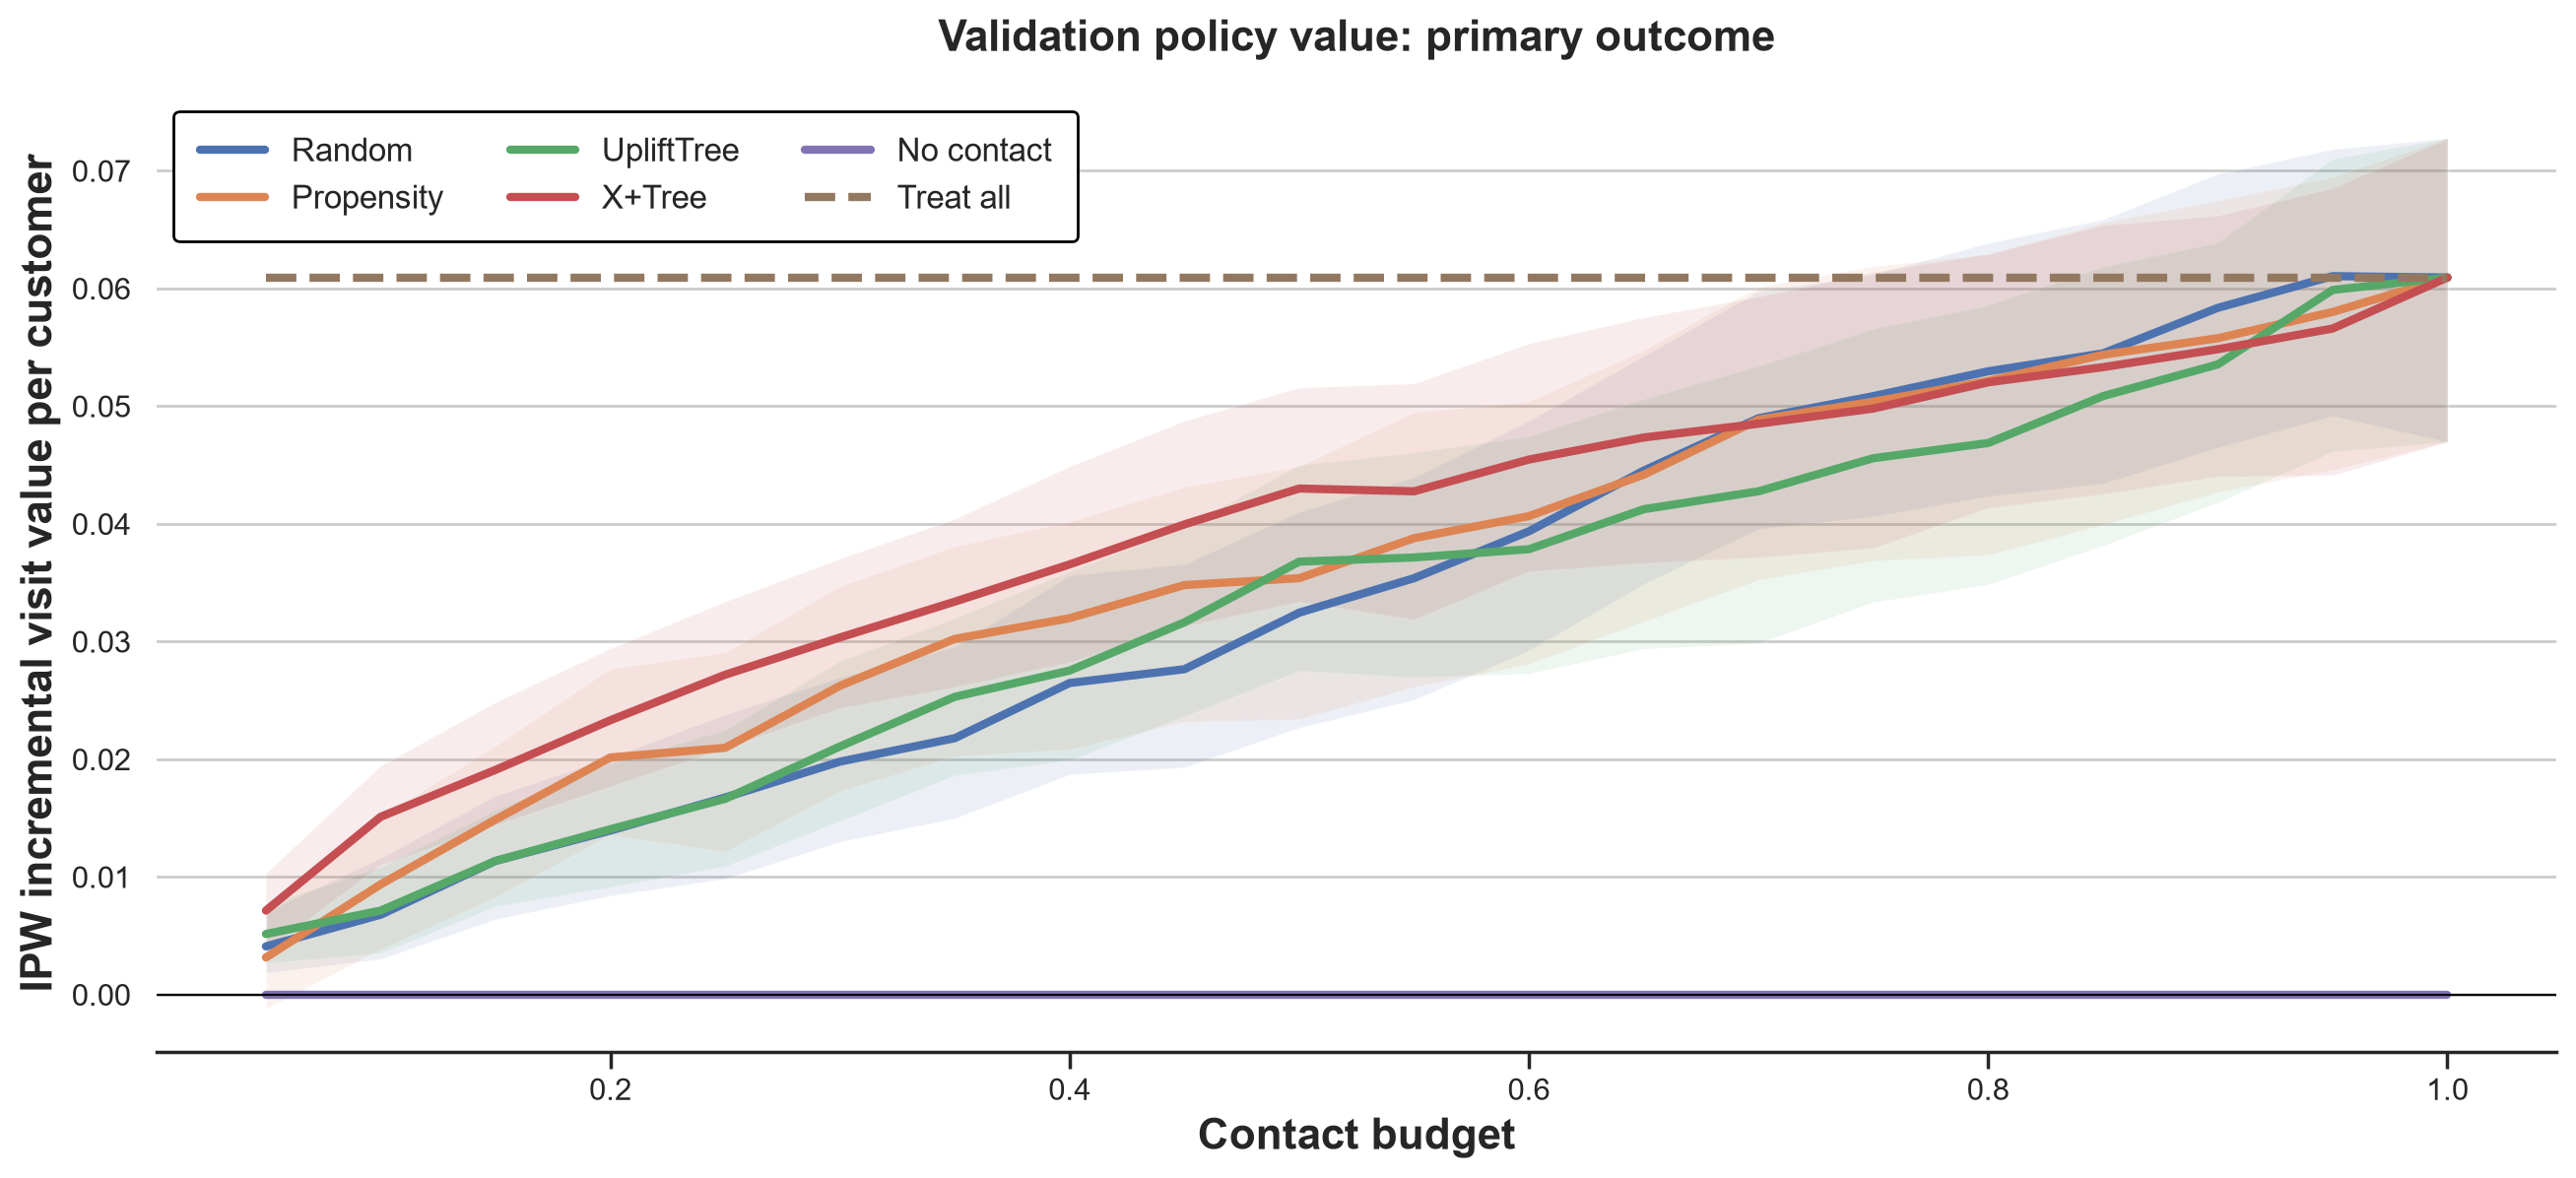

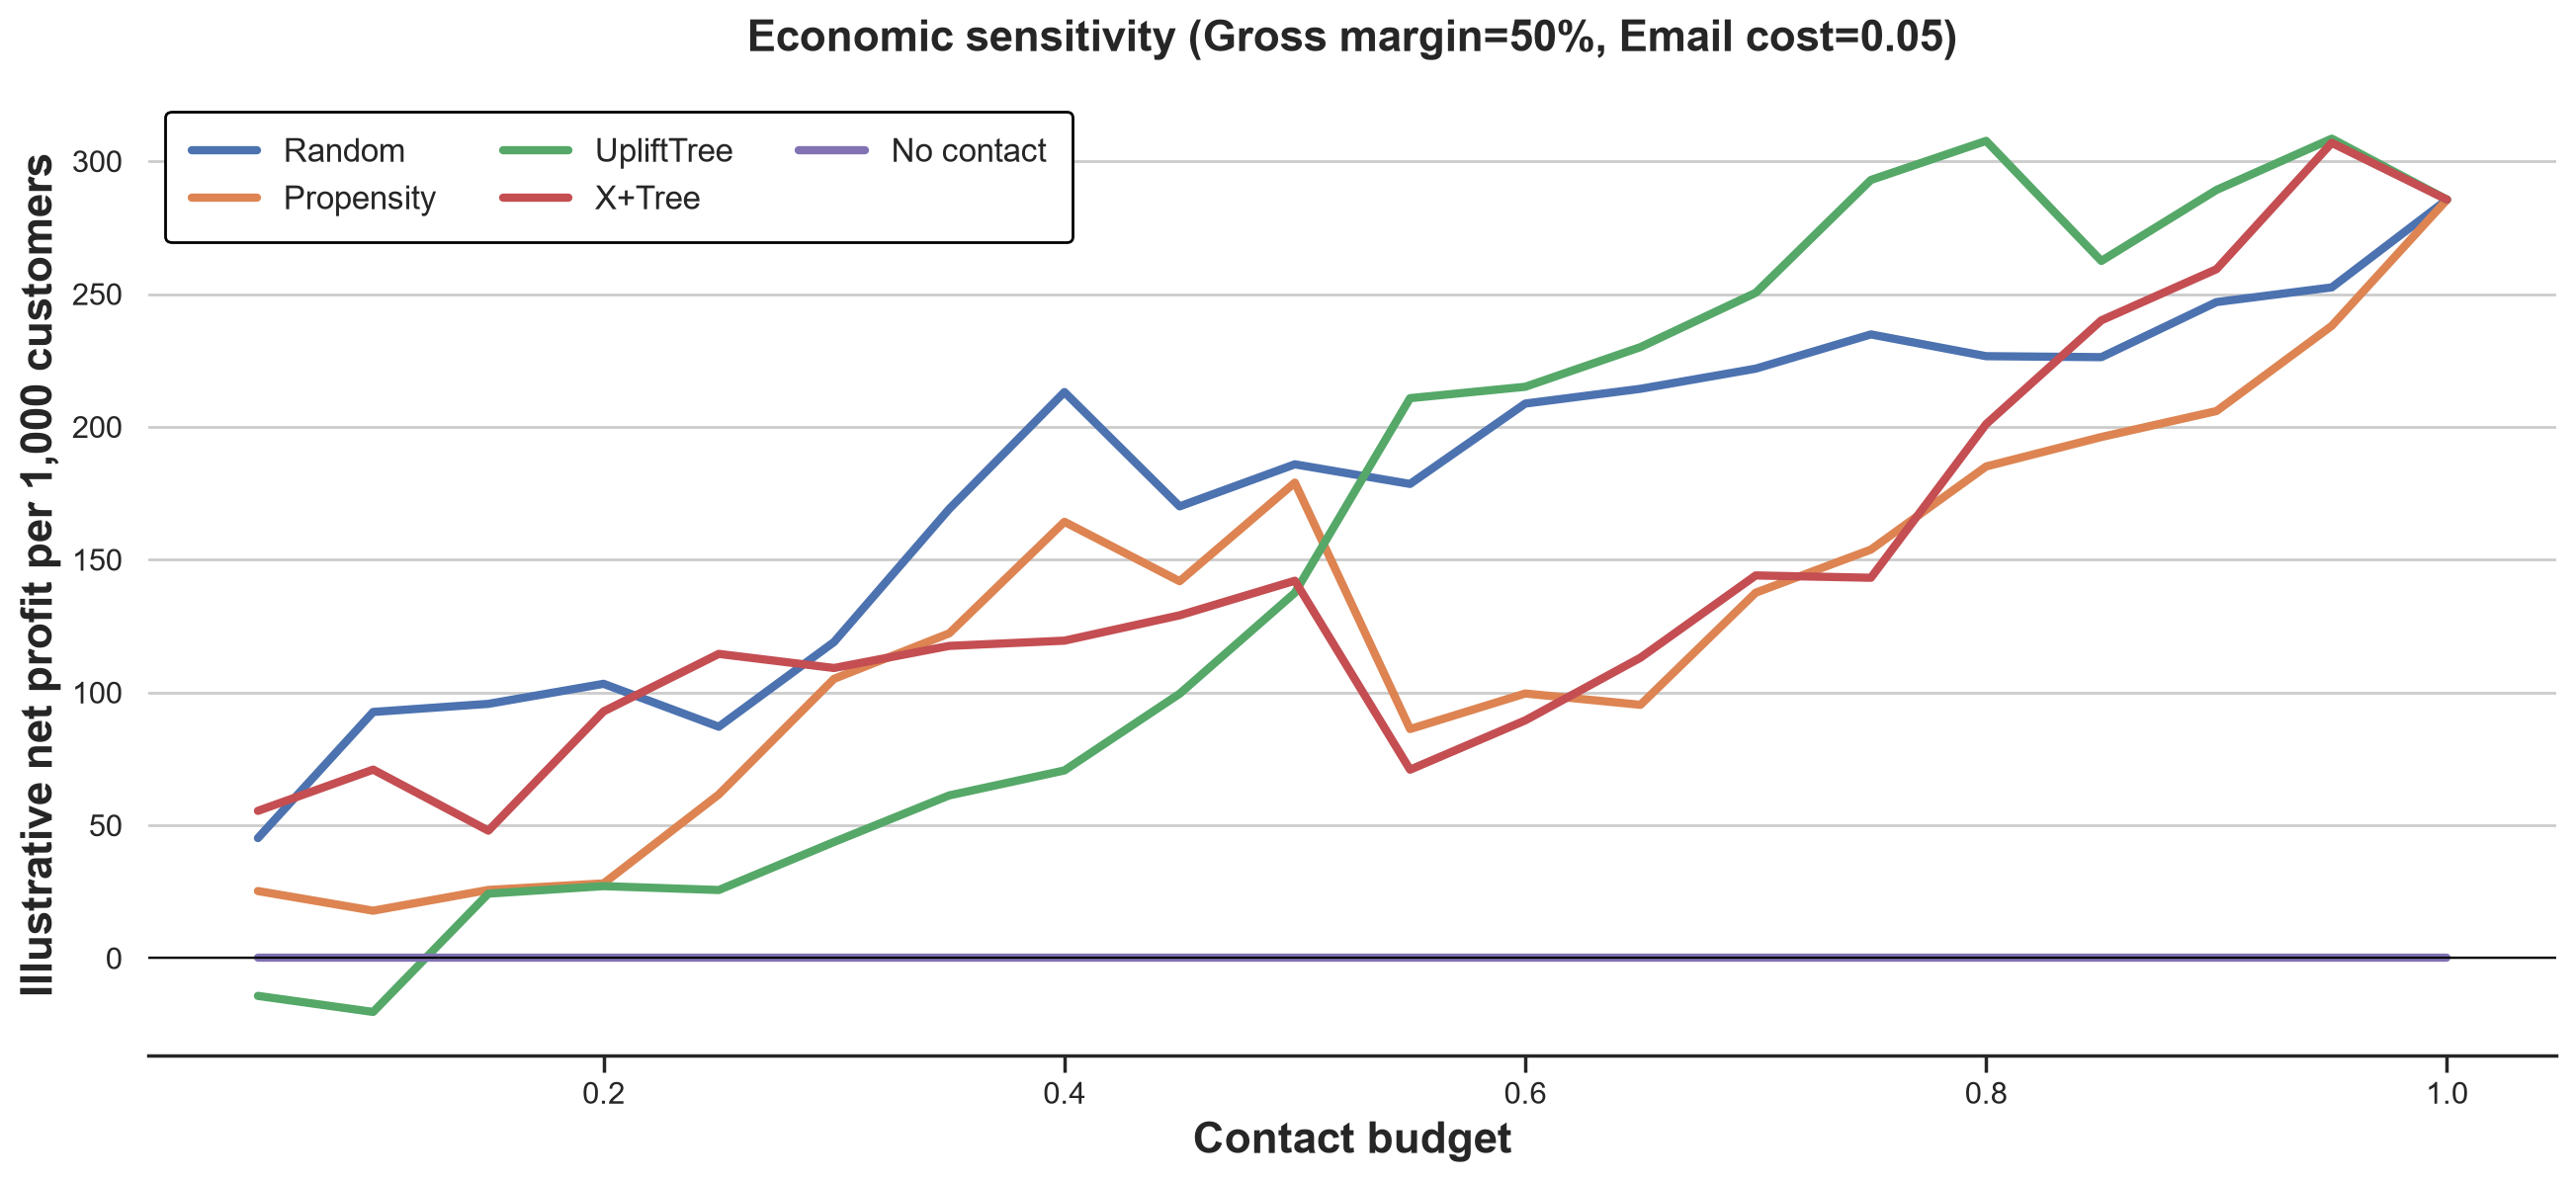

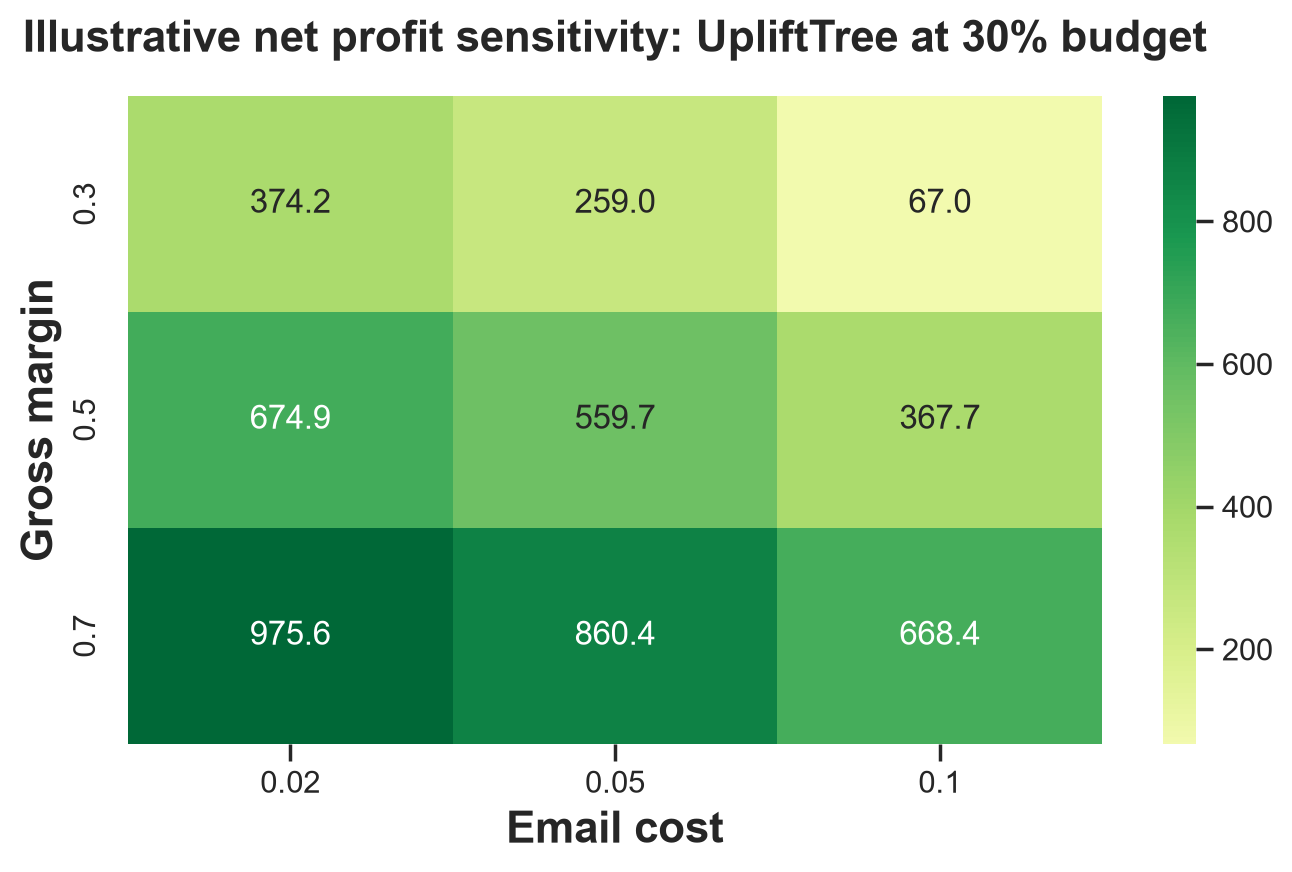

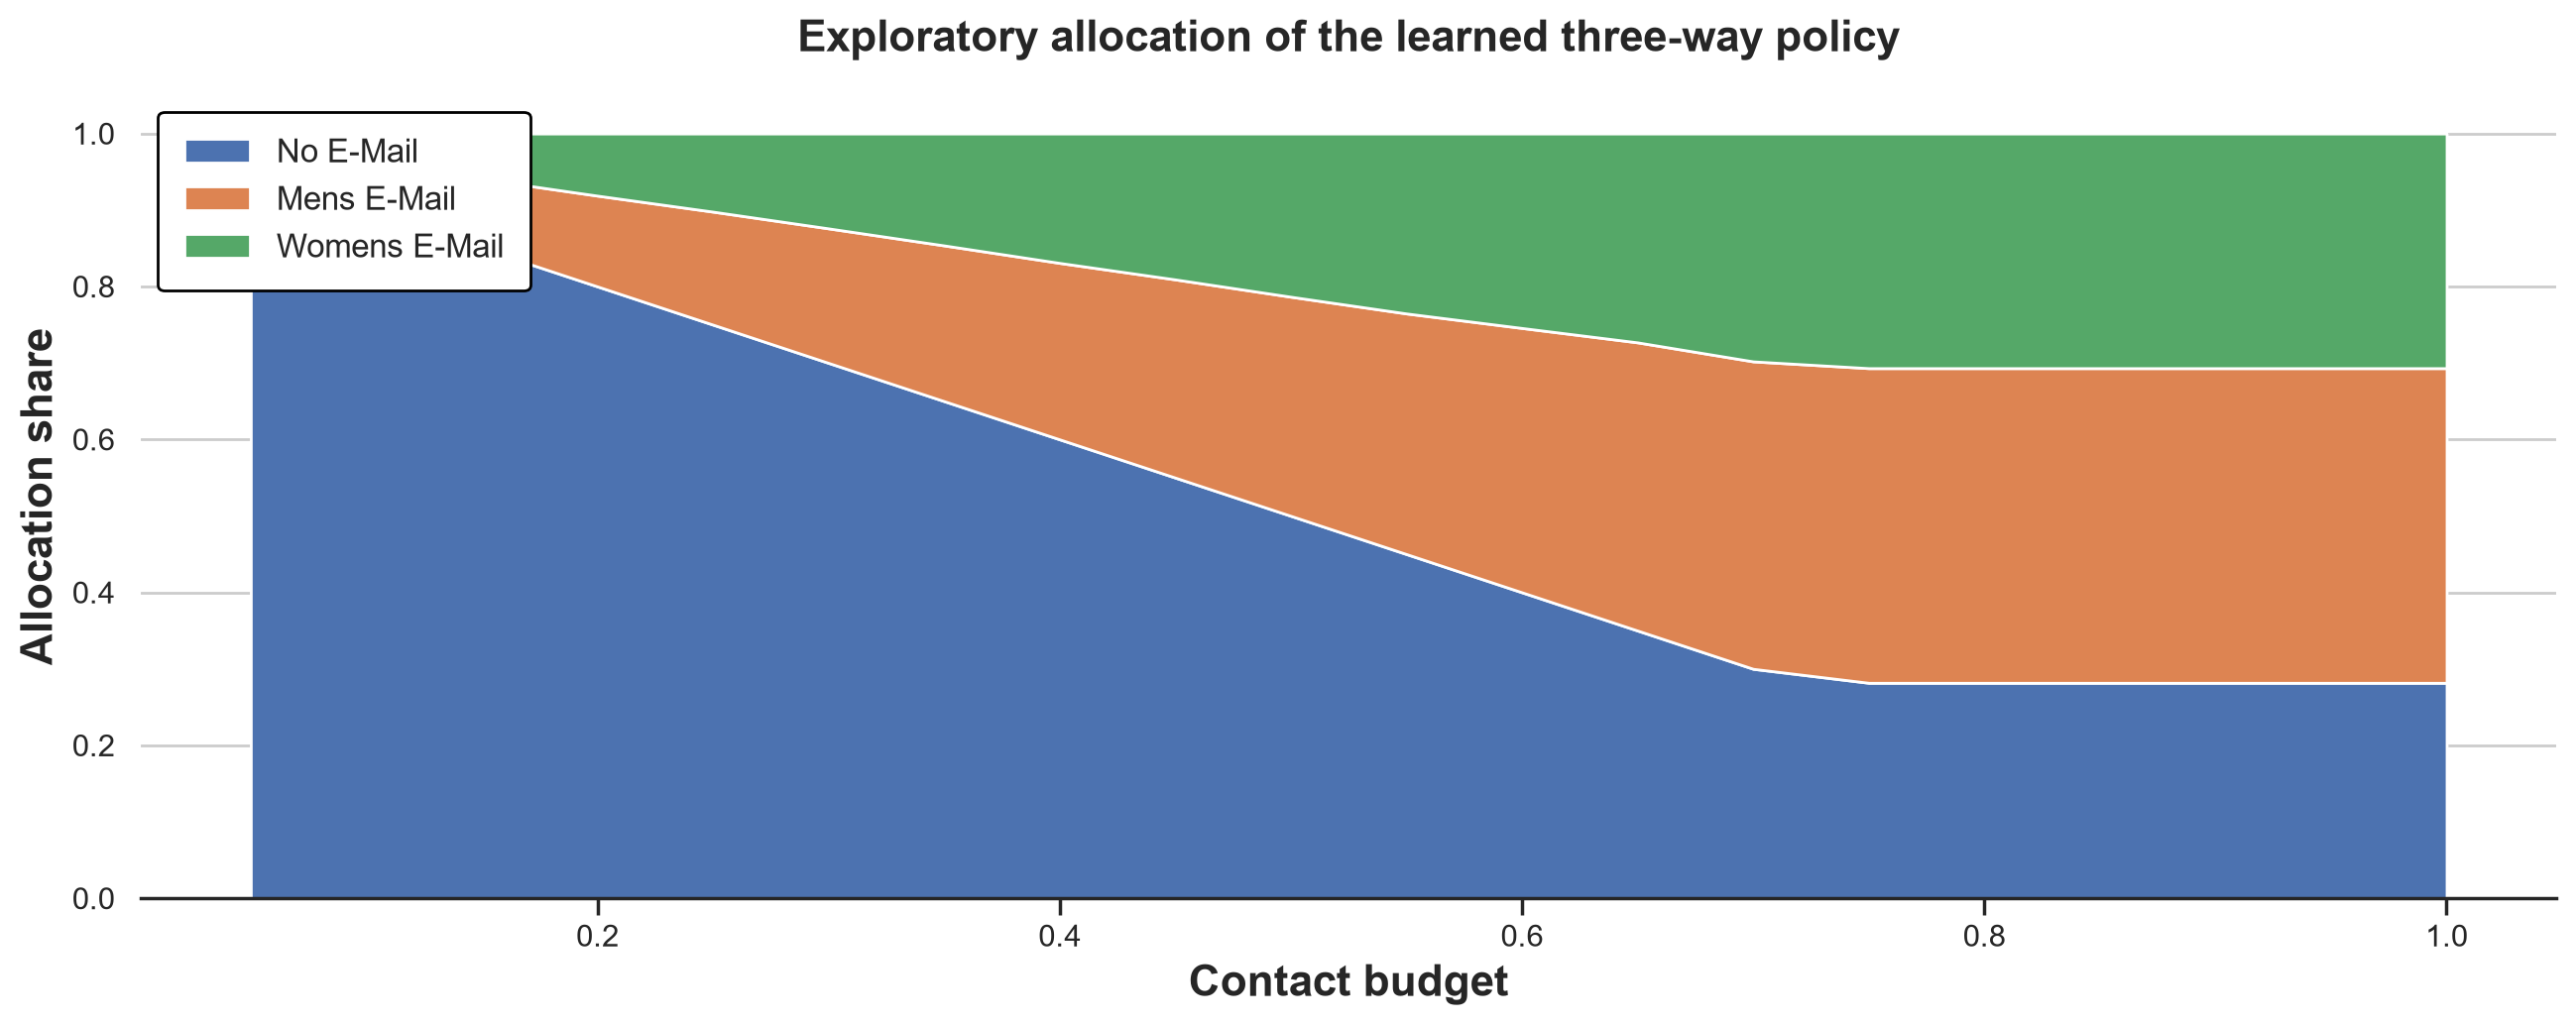

[<Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 700x400 with 2 Axes>,
 <Figure size 1400x500 with 1 Axes>]

In [2]:
report = build_s8_policy_report(train_df, val_df, seed=SEED)
save_s8_policy_artifacts(report, ARTIFACTS_S8_DIR)
display_s8_policy_report(report, lang=lang, artifacts_dir=ARTIFACTS_S8_DIR)
plot_s8_policy_report(report, lang=lang)


<a id="s8-5"></a>

## 5. Responsible reading

The artifacts compare incremental value, uncertainty and economic sensitivity across the full budget grid. They do not change S6, turn a validation result into confirmatory evidence or authorize a claim that uplift beat propensity targeting.
